## Task 1  
## Prove why we visualize (datasaurus.csv)
1,846 rows, 3 columns: dataset, x, y. It contains 13 different datasets of 142 points each.

# Compute the mean and standard deviation
**Compute the mean of x, mean of y, standard deviation of both, and the correlation between them — for each of the 13 datasets. Present it as one table.**

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("week 01 dataset\datasaurus.csv")

# Calculate statistics for each dataset
summary = df.groupby("dataset").agg(
    mean_x=("x", "mean"),
    mean_y=("y", "mean"),
    std_x=("x", "std"),
    std_y=("y", "std")
).reset_index()

# Add correlation
correlations = df.groupby("dataset").apply(
    lambda group: group["x"].corr(group["y"])
)

summary["correlation"] = summary["dataset"].map(correlations)

# Round values
summary = summary.round(2)

print(summary)

<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\M Saeed\AppData\Local\Temp\ipykernel_8408\3816529557.py:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df = pd.read_csv("week 01 dataset\datasaurus.csv")


       dataset  mean_x  mean_y  std_x  std_y  correlation
0         away   54.27   47.83  16.77  26.94        -0.06
1     bullseye   54.27   47.83  16.77  26.94        -0.07
2       circle   54.27   47.84  16.76  26.93        -0.07
3         dino   54.26   47.83  16.77  26.94        -0.06
4         dots   54.26   47.84  16.77  26.93        -0.06
5      h_lines   54.26   47.83  16.77  26.94        -0.06
6   high_lines   54.27   47.84  16.77  26.94        -0.07
7   slant_down   54.27   47.84  16.77  26.94        -0.07
8     slant_up   54.27   47.83  16.77  26.94        -0.07
9         star   54.27   47.84  16.77  26.93        -0.06
10     v_lines   54.27   47.84  16.77  26.94        -0.07
11  wide_lines   54.27   47.83  16.77  26.94        -0.07
12     x_shape   54.26   47.84  16.77  26.93        -0.07


# 2. Conclude
**Look at your table. Write down what you would conclude if the table were all you had.**

If I only had the summary-statistics table, I would probably conclude that:

All 13 datasets are very similar. Their means, standard deviations, and correlations are almost identical. The correlation is close to zero in every dataset, suggesting that there is little or no linear relationship between x and y. I might therefore assume that the datasets have roughly similar distributions and similar relationships between their variables.

However, this conclusion would be misleading.

The table tells us only about the center, spread, and linear association of the data. It does not tell us the actual shape or structure of the observations.

# 3. Plot
**Now plot all 13 as a grid of scatter plots.**


<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\M Saeed\AppData\Local\Temp\ipykernel_8408\2754129234.py:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df = pd.read_csv("week 01 dataset\datasaurus.csv")


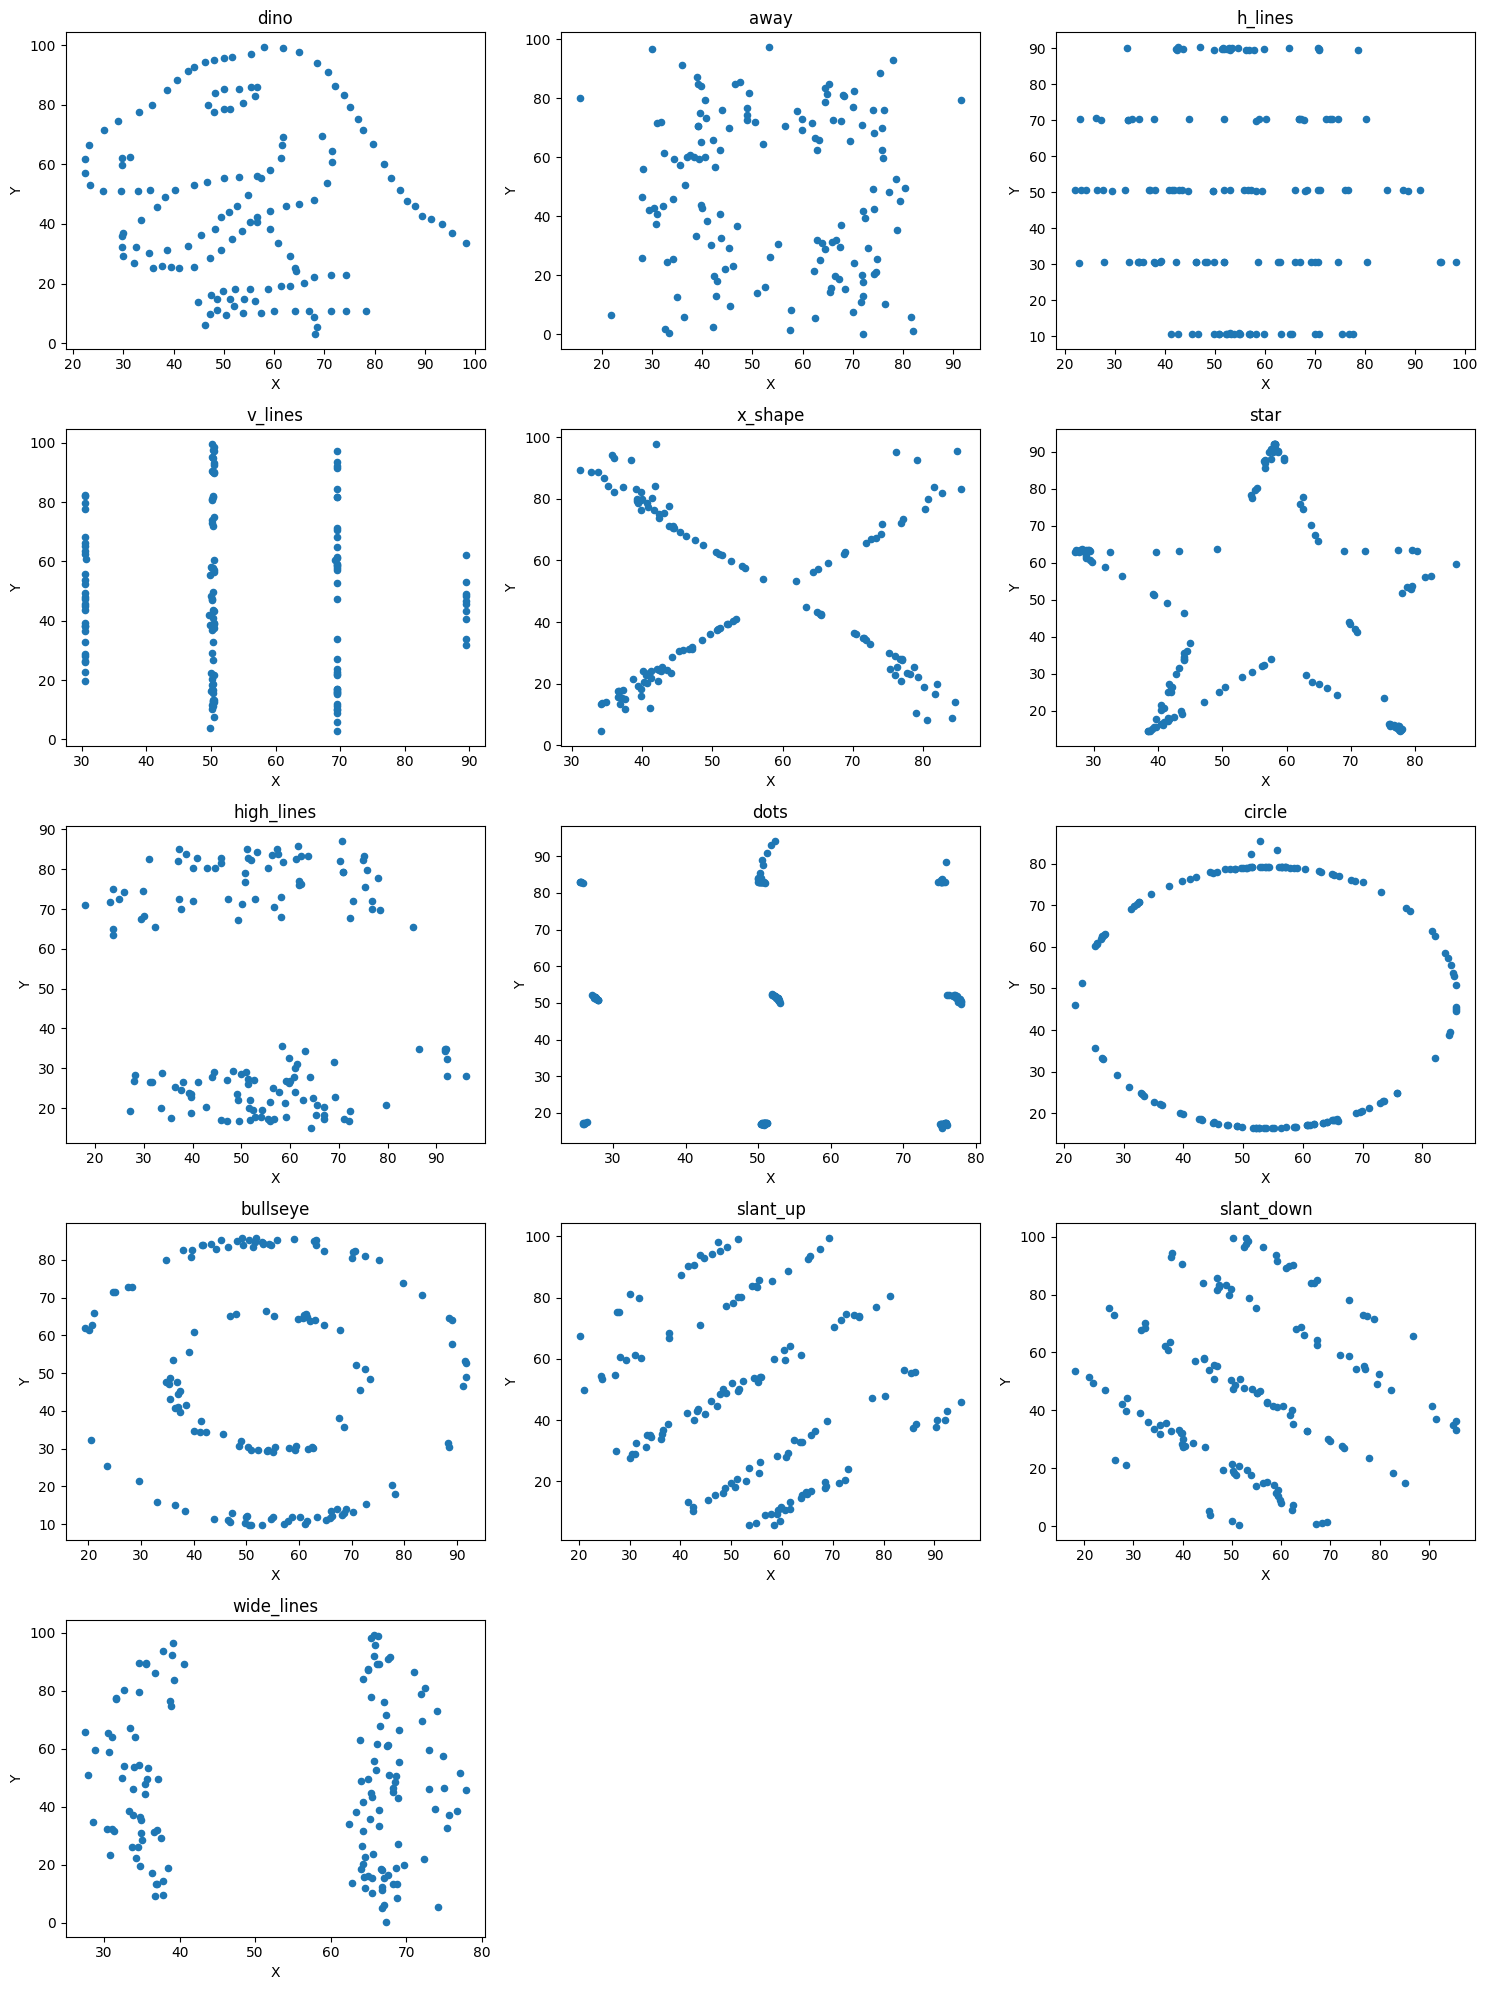

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("week 01 dataset\datasaurus.csv")

# Get dataset names
datasets = df["dataset"].unique()

# Create 5 x 3 grid
fig, axes = plt.subplots(5, 3, figsize=(15, 20))

# Flatten axes
axes = axes.flatten()

# Plot each dataset
for ax, name in zip(axes, datasets):

    data = df[df["dataset"] == name]

    ax.scatter(data["x"], data["y"], s=20)

    ax.set_title(name)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

# Hide unused subplot
for ax in axes[len(datasets):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# 4. Actually find
**What do you actually find?**

After plotting the data, the surprising result is that the 13 datasets are very different despite having almost identical summary statistics.

For example:

dino forms the shape of a dinosaur.

circle forms a roughly circular pattern.

bullseye has a circular/target-like structure.

star forms a star-like shape.

x_shape forms an X.

h_lines consists mainly of horizontal structures.

v_lines contains vertical structures.

slant_up and slant_down have directional patterns.

dots has concentrated clusters.


So although their means are around X = 54.27 and Y = 47.84, and their correlations are around −0.06 to −0.07, their actual distributions are dramatically different.

# The question to answer
**we saw this effect with Anscombe's 4 datasets. Does having 13 datasets, and 142 points each instead of 11, make the summary statistics any more trustworthy? Why or why not?**

The results show that having more observations does not necessarily make summary statistics sufficient for understanding a dataset. All 13 datasets contain 142 observations, yet their means, standard deviations, and correlations are almost identical. If we looked only at the summary table, we might conclude that the datasets are very similar and that there is almost no relationship between x and y. However, the scatter plots reveal completely different patterns, including a dinosaur, circle, star, X-shape, and different line patterns. Therefore, the larger sample size makes the calculated statistics more precise, but it does not make them complete or fully trustworthy as a description of the data. Just as with Anscombe's Quartet, this example shows that summary statistics should be combined with visualization because important patterns can be hidden by numerical summaries alone.


**142 points give us more precision, but visualization gives us information that mean, standard deviation, and correlation cannot provide**